# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

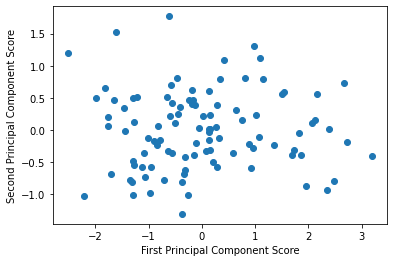

In [1]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

**Three outliers in the upper left corner of the graph:**

The three outliers in the upper left corner have low values for the first principal component score and high values for the second principal component score. This positioning sets them apart from the majority of the data points.

**The first principal component score:**

Their first principal component score is low. This can be seen from their position on the far left side of the horizontal axis in the scatter plot.

**second principal component score:**

Their second principal component score is high, as they appear near the top of the vertical axis in the scatter plot.

**What does that mean about their values in series_1, series_2, and series_3?**

Since the first principal component is mostly influenced by series_3 (with a component loading of approximately 0.916), a low PC1 score suggests that the values in series_3 are low for these outliers. The second principal component is a mix of series_1 and series_2 (with positive loadings) and negatively influenced by series_3, so a high PC2 score indicates relatively high values in series_1 and series_2.

**About series_3 **

These outliers have significantly low values in series_3, since PC1 is largely driven by series_3 and the scores are very low in that component for these points.

**Series_1 and series_2 are highly correlated:**  

PCA treats them as carrying similar information, so it does not separate them cleanly. The loadings in the components mix them together, making it hard to distinguish which of the two is relatively higher or lower for specific data points. The principal components capture shared variation rather than differences between these two.

**How are series_1 and series_2 related:**

series_2 was created by multiplying series_1 by a small amount of random noise centered around 1. This means that series_2 is almost a scaled version of series_1, making them strongly positively correlated.

**Advantages and disadvantages of the graph**

**Advantages:**

- The scatter plot effectively reveals underlying structure in the data using dimensionality reduction.

- It shows clusters and outliers, like the three in the upper left corner.

- It highlights that most of the variation is captured by the first component, which relates to series_3.

**Disadvantages:**

- The graph does not provide specific insight into the original variables unless we examine the component loadings.

- It is hard to distinguish between variables that are highly correlated, like series_1 and series_2.

- It can be misleading if overinterpreted without understanding PCA math.


# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

In [2]:
#first dataset: airbnb

file_path = "/Users/sohanaziz/Documents/AI for leaders sem 2/Datasets/cleaned datasets/week 2/cleaned_airbnb_data.csv" 
df = pd.read_csv(file_path)

print(df.info())   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14448 entries, 0 to 14447
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14448 non-null  int64  
 1   name                            14448 non-null  object 
 2   host_id                         14448 non-null  int64  
 3   host_name                       14448 non-null  object 
 4   neighbourhood                   14448 non-null  object 
 5   latitude                        14448 non-null  float64
 6   longitude                       14448 non-null  float64
 7   room_type                       14448 non-null  object 
 8   price                           14448 non-null  float64
 9   minimum_nights                  14448 non-null  int64  
 10  number_of_reviews               14448 non-null  int64  
 11  last_review                     12243 non-null  object 
 12  reviews_per_month               

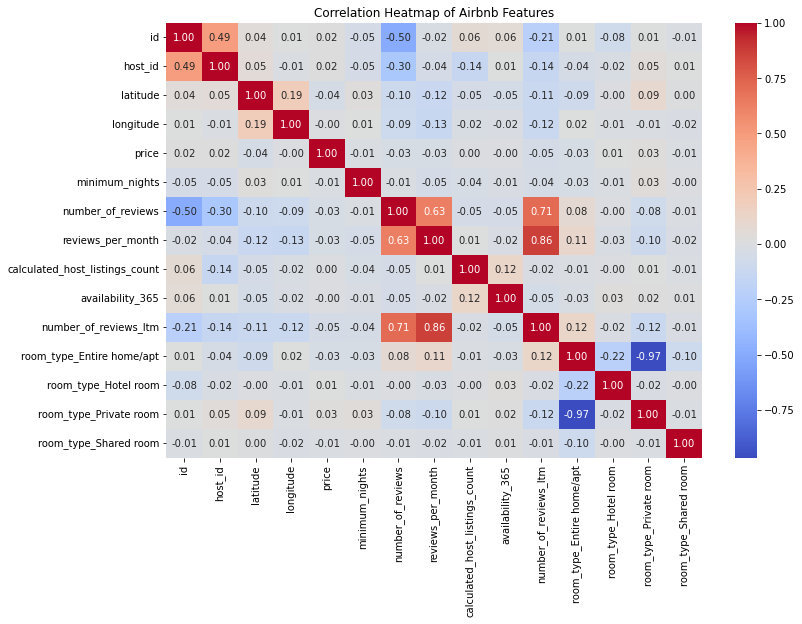

In [5]:
import seaborn as sns

# Select only numeric columns
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Compute correlation matrix
correlation_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Airbnb Features')
plt.show()

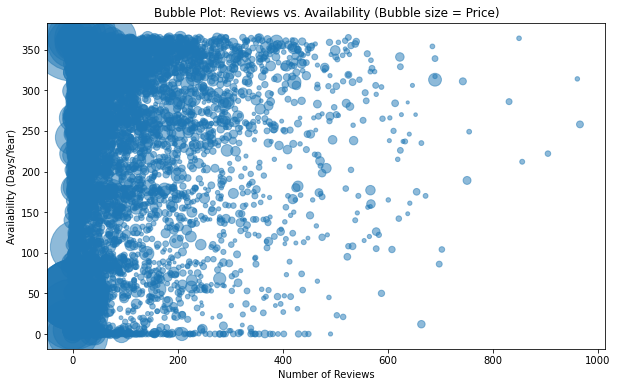

In [6]:
# Bubble plot

plt.figure(figsize=(10, 6))
plt.scatter(df['number_of_reviews'], df['availability_365'], 
            s=df['price']/2, alpha=0.5)
plt.xlabel("Number of Reviews")
plt.ylabel("Availability (Days/Year)")
plt.title("Bubble Plot: Reviews vs. Availability (Bubble size = Price)")
plt.show()

In [7]:
# PCA

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Select numerical features
features = ['latitude', 'longitude', 'price', 'minimum_nights',
            'number_of_reviews', 'reviews_per_month',
            'calculated_host_listings_count', 'availability_365',
            'number_of_reviews_ltm']

X = df[features]
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=3)
pca.fit(X_scaled)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.28188286 0.13594856 0.11742431]


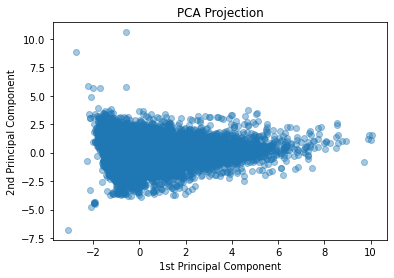

In [8]:
#Projection on 1st PC

X_pca = pca.transform(X_scaled)
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.4)
plt.xlabel("1st Principal Component")
plt.ylabel("2nd Principal Component")
plt.title("PCA Projection")
plt.show()

In [10]:
# Linear regression

correlation_matrix['price'].sort_values(ascending=False)


price                             1.000000
room_type_Private room            0.029527
id                                0.023580
host_id                           0.022041
room_type_Hotel room              0.010989
calculated_host_listings_count    0.001693
longitude                        -0.000190
availability_365                 -0.001816
room_type_Shared room            -0.007490
minimum_nights                   -0.012156
reviews_per_month                -0.029774
room_type_Entire home/apt        -0.030502
number_of_reviews                -0.032016
latitude                         -0.043723
number_of_reviews_ltm            -0.045340
Name: price, dtype: float64

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Features to use (excluding id/host_id, keeping dummy variables for room types)
features = [
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'calculated_host_listings_count',
    'availability_365',
    'number_of_reviews_ltm',
    'latitude',
    'longitude',
    'room_type_Entire home/apt',
    'room_type_Hotel room',
    'room_type_Private room',
    'room_type_Shared room'
]

# Target
target = 'price'

# Define X and y
X = df[features]
y = df[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [14]:
# Fit linear regression
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.2f}")

Mean Squared Error: 79360.60
R² Score: 0.01


In [15]:
# Coefficients
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

print(coef_df)

                           Feature  Coefficient
7                        longitude   163.742012
9             room_type_Hotel room    50.408041
10          room_type_Private room    27.232519
2                reviews_per_month     5.833145
8        room_type_Entire home/apt     2.661617
4                 availability_365    -0.005190
1                number_of_reviews    -0.009866
3   calculated_host_listings_count    -0.060276
0                   minimum_nights    -0.394833
5            number_of_reviews_ltm    -1.095679
11           room_type_Shared room   -80.302177
6                         latitude -1120.357915


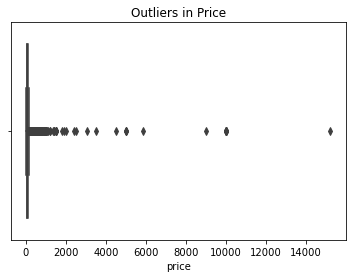

In [16]:
sns.boxplot(x=df['price'])
plt.title("Outliers in Price")
plt.show()

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

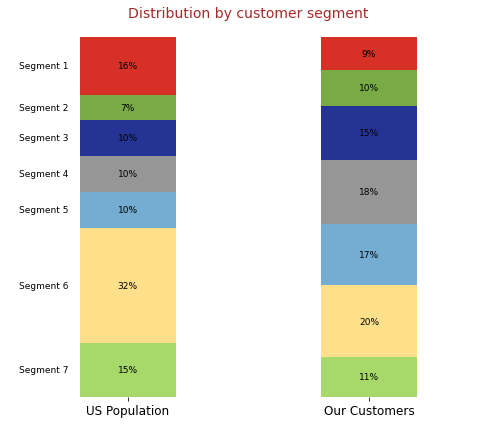

In [18]:
# Data
segments = ['Segment 1', 'Segment 2', 'Segment 3', 'Segment 4',
            'Segment 5', 'Segment 6', 'Segment 7']

us_population = [16, 7, 10, 10, 10, 32, 15]
our_customers = [9, 10, 15, 18, 17, 20, 11]

colors = ['#d73027', '#78ab46', '#253494', '#969696', '#74add1', '#fee08b', '#a6d96a']

# Reverse data for stacking from top to bottom
segments = segments[::-1]
us_population = us_population[::-1]
our_customers = our_customers[::-1]
colors = colors[::-1]

# Setup
fig, ax = plt.subplots(figsize=(7, 6))
x_labels = ['US Population', 'Our Customers']
bar_width = 0.4

# Stack bars
us_bottom = 0
our_bottom = 0
for i in range(len(segments)):
    ax.bar(0, us_population[i], bottom=us_bottom, color=colors[i], width=bar_width)
    ax.bar(1, our_customers[i], bottom=our_bottom, color=colors[i], width=bar_width)

    # Add percentages inside the bars
    ax.text(0, us_bottom + us_population[i]/2, f"{us_population[i]}%", ha='center', va='center', fontsize=9, color='black')
    ax.text(1, our_bottom + our_customers[i]/2, f"{our_customers[i]}%", ha='center', va='center', fontsize=9, color='black')

    us_bottom += us_population[i]
    our_bottom += our_customers[i]

# Title and axis settings
ax.set_title("Distribution by customer segment", fontsize=14, color='brown', pad=20)
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(0, 100)
ax.set_xticks([0, 1])
ax.set_xticklabels(x_labels, fontsize=12)
ax.set_yticks([])

# Remove borders for cleaner look
for spine in ax.spines.values():
    spine.set_visible(False)

# Segment labels on the left
segment_pos = np.cumsum(us_population) - np.array(us_population) / 2
for i, segment in enumerate(segments):
    ax.text(-0.45, segment_pos[i], segment, fontsize=9, va='center')

plt.tight_layout()
plt.show()